# 03 Macro Regime Indicators

**Book:** *Global Macro Trading — Profiting in a New World Economy*  
**Focus:** Build a reusable macro regime panel from local FRED data and compare simple cross-asset behavior across those regimes.


## Goals

1. Load the local FRED macro, rates, credit, and liquidity inputs available in this repo.
2. Build composite growth, inflation, stress, and liquidity signals using only local data.
3. Classify each business day into four practical macro regimes:
   - inflation shock
   - growth scare
   - stable carry
   - funding stress
4. Save the daily regime panel so the other Global Macro Trading notebooks can import it.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

REPO_ROOT = Path("/Users/zelin/Desktop/PA Investment/Invest_strategy")
STUDY_DIR = REPO_ROOT / "workstation" / "playground" / "studies" / "2026-03-27_global_macro_trading_gliner"
FRED_DIR = REPO_ROOT / "data" / "market_data" / "fred"
PRICES_DIR = REPO_ROOT / "data" / "market_data" / "prices"

START = "2024-02-26"
END = "2026-02-27"

REGIME_PARQUET = STUDY_DIR / "macro_regime_daily.parquet"
REGIME_CSV = STUDY_DIR / "macro_regime_daily.csv"
ASSET_SUMMARY_CSV = STUDY_DIR / "macro_regime_asset_summary.csv"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Study dir:", STUDY_DIR)
print("FRED dir exists:", FRED_DIR.exists())
print("Price dir exists:", PRICES_DIR.exists())


Study dir: /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-27_global_macro_trading_gliner
FRED dir exists: True
Price dir exists: True


In [2]:
def _filter_date(frame: pd.DataFrame, start=START, end=END, date_col="date"):
    out = frame.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    return out[(out[date_col] >= start) & (out[date_col] <= end)]


def load_fred_series(series_ids, start=START, end=END):
    frames = []
    for parquet_file in sorted(FRED_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "series_id" not in df.columns:
            continue
        sub = df[df["series_id"].isin(series_ids)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    if not frames:
        return pd.DataFrame()

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "series_id"])
    wide = (
        joined.pivot(index="date", columns="series_id", values="value")
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide


def load_local_price_series(tickers, start=START, end=END, value_col="close"):
    frames = []
    for parquet_file in sorted(PRICES_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "ticker" not in df.columns or value_col not in df.columns:
            continue
        sub = df[df["ticker"].isin(tickers)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    if not frames:
        return pd.DataFrame()

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "ticker"])
    wide = (
        joined.pivot(index="date", columns="ticker", values=value_col)
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide


def rolling_zscore(series: pd.Series, window=60, min_periods=20):
    rolling_mean = series.rolling(window, min_periods=min_periods).mean()
    rolling_std = series.rolling(window, min_periods=min_periods).std(ddof=1)
    return (series - rolling_mean) / rolling_std.replace(0.0, np.nan)


In [3]:
fred_series = [
    "SOFR",
    "DFEDTARU",
    "DGS10",
    "T10Y2Y",
    "T10Y3M",
    "T5YIE",
    "T10YIE",
    "BAMLH0A0HYM2",
    "UNRATE",
    "UMCSENT",
    "CPIAUCSL",
    "NFCI",
    "WALCL",
    "WRESBAL",
    "RRPONTSYD",
]

macro_raw = load_fred_series(fred_series).sort_index()
business_days = pd.date_range(START, END, freq="B")
macro_panel = macro_raw.reindex(business_days).ffill()
macro_panel.index.name = "date"

print("Loaded series:", list(macro_panel.columns))
macro_panel[fred_series].tail()


Loaded series: ['BAMLH0A0HYM2', 'CPIAUCSL', 'DFEDTARU', 'DGS10', 'NFCI', 'RRPONTSYD', 'SOFR', 'T10Y2Y', 'T10Y3M', 'T10YIE', 'T5YIE', 'UMCSENT', 'UNRATE', 'WALCL', 'WRESBAL']


series_id   SOFR  DFEDTARU  DGS10  T10Y2Y  T10Y3M  T5YIE  T10YIE  BAMLH0A0HYM2  UNRATE  UMCSENT  CPIAUCSL     NFCI      WALCL    WRESBAL  RRPONTSYD
date                                                                                                                                               
2026-02-23  3.66      3.75   4.03    0.60    0.34   2.40    2.26          2.95     4.3     56.4   326.588 -0.56294  6613395.0  2949804.0      0.877
2026-02-24  3.67      3.75   4.03    0.61    0.35   2.40    2.26          2.97     4.3     56.4   326.588 -0.56294  6613395.0  2949804.0      0.917
2026-02-25  3.67      3.75   4.05    0.60    0.36   2.42    2.28          2.94     4.3     56.4   326.588 -0.56294  6613797.0  2965765.0      1.159
2026-02-26  3.67      3.75   4.05    0.60    0.34   2.43    2.28          2.98     4.3     56.4   326.588 -0.56294  6613797.0  2965765.0      3.796
2026-02-27  3.67      3.75   4.05    0.59    0.30   2.40    2.25          2.98     4.3     56.4   326.588 -0.562

In [4]:
macro_panel["policy_gap"] = macro_panel["SOFR"] - macro_panel["DFEDTARU"]
macro_panel["curve_combo"] = 0.5 * (macro_panel["T10Y2Y"] + macro_panel["T10Y3M"])
macro_panel["breakeven_avg"] = 0.5 * (macro_panel["T5YIE"] + macro_panel["T10YIE"])

# Approximate 3-month annualized inflation using 63 business-day spacing after forward-fill.
macro_panel["cpi_3m_ann"] = ((macro_panel["CPIAUCSL"] / macro_panel["CPIAUCSL"].shift(63)) ** 4 - 1.0) * 100.0
macro_panel["unrate_3m_change"] = macro_panel["UNRATE"] - macro_panel["UNRATE"].shift(63)
macro_panel["sentiment_3m_change"] = macro_panel["UMCSENT"] - macro_panel["UMCSENT"].shift(63)

# Weekly balance-sheet and liquidity proxies, converted to 13-week percentage changes.
macro_panel["walcl_13w_pct"] = macro_panel["WALCL"].pct_change(65) * 100.0
macro_panel["wresbal_13w_pct"] = macro_panel["WRESBAL"].pct_change(65) * 100.0
macro_panel["rrp_13w_pct"] = macro_panel["RRPONTSYD"].pct_change(65) * 100.0

feature_cols = [
    "policy_gap",
    "curve_combo",
    "breakeven_avg",
    "cpi_3m_ann",
    "unrate_3m_change",
    "sentiment_3m_change",
    "walcl_13w_pct",
    "wresbal_13w_pct",
    "rrp_13w_pct",
]
macro_panel[feature_cols].tail(10)


series_id   policy_gap  curve_combo  breakeven_avg  cpi_3m_ann  unrate_3m_change  sentiment_3m_change  walcl_13w_pct  wresbal_13w_pct  rrp_13w_pct
date                                                                                                                                              
2026-02-16       -0.09        0.500          2.345    2.921887              -0.1                  2.8       0.637037         2.960634   -88.114754
2026-02-17       -0.04        0.490          2.325    2.921887              -0.1                  2.8       0.637037         2.960634   -51.270718
2026-02-18       -0.02        0.505          2.360    2.921887              -0.1                  2.8       0.886491         2.117292   -24.180691
2026-02-19       -0.08        0.500          2.360    2.921887              -0.1                  2.8       0.886491         2.117292   -90.306748
2026-02-20       -0.09        0.495          2.355    2.921887              -0.1                  2.8       0.886491  

In [5]:
macro_panel["curve_signal"] = rolling_zscore(macro_panel["curve_combo"])
macro_panel["labor_signal"] = rolling_zscore(-macro_panel["unrate_3m_change"])
macro_panel["sentiment_signal"] = rolling_zscore(macro_panel["sentiment_3m_change"])
macro_panel["growth_signal"] = macro_panel[["curve_signal", "labor_signal", "sentiment_signal"]].mean(axis=1)

macro_panel["inflation_market_signal"] = rolling_zscore(macro_panel["breakeven_avg"])
macro_panel["inflation_realized_signal"] = rolling_zscore(macro_panel["cpi_3m_ann"])
macro_panel["inflation_signal"] = macro_panel[["inflation_market_signal", "inflation_realized_signal"]].mean(axis=1)

macro_panel["credit_signal"] = rolling_zscore(macro_panel["BAMLH0A0HYM2"])
macro_panel["financial_conditions_signal"] = rolling_zscore(macro_panel["NFCI"])
macro_panel["policy_gap_signal"] = rolling_zscore(macro_panel["policy_gap"])
macro_panel["stress_signal"] = macro_panel[["credit_signal", "financial_conditions_signal", "policy_gap_signal"]].mean(axis=1)

macro_panel["walcl_signal"] = rolling_zscore(macro_panel["walcl_13w_pct"])
macro_panel["wresbal_signal"] = rolling_zscore(macro_panel["wresbal_13w_pct"])
macro_panel["rrp_signal"] = -rolling_zscore(macro_panel["rrp_13w_pct"])
macro_panel["liquidity_signal"] = macro_panel[["walcl_signal", "wresbal_signal", "rrp_signal"]].mean(axis=1)

signal_cols = [
    "growth_signal",
    "inflation_signal",
    "stress_signal",
    "liquidity_signal",
    "curve_signal",
    "labor_signal",
    "sentiment_signal",
    "inflation_market_signal",
    "inflation_realized_signal",
    "credit_signal",
    "financial_conditions_signal",
    "policy_gap_signal",
]
macro_panel[signal_cols].tail(10)


series_id   growth_signal  inflation_signal  stress_signal  liquidity_signal  curve_signal  labor_signal  sentiment_signal  inflation_market_signal  inflation_realized_signal  credit_signal  financial_conditions_signal  policy_gap_signal
date                                                                                                                                                                                                                                         
2026-02-16       0.308620          0.537798      -0.152379          0.951347     -0.800505      0.852092          0.874272                 0.405780                   0.669816       1.001883                    -1.000222          -0.458799
2026-02-17       0.230840          0.369555       0.150878          0.869338     -1.000943      0.842051          0.851411                 0.092850                   0.646260       1.084237                    -0.971142           0.339539
2026-02-18       0.245344          0.606759     

In [6]:
def classify_regime(row):
    if row["stress_signal"] >= 0.85:
        return "funding stress"
    if row["inflation_signal"] >= 0.75 and row["growth_signal"] > -0.75:
        return "inflation shock"
    if row["growth_signal"] <= -0.50 and row["inflation_signal"] <= 0.75:
        return "growth scare"
    return "stable carry"


regime_panel = macro_panel.dropna(subset=["growth_signal", "inflation_signal", "stress_signal", "liquidity_signal"]).copy()
regime_panel["regime"] = regime_panel.apply(classify_regime, axis=1)
regime_panel["regime_code"] = regime_panel["regime"].map({
    "inflation shock": 0,
    "growth scare": 1,
    "stable carry": 2,
    "funding stress": 3,
})

regime_order = ["inflation shock", "growth scare", "stable carry", "funding stress"]
regime_counts = (
    regime_panel["regime"].value_counts().reindex(regime_order).fillna(0).astype(int).rename_axis("regime").to_frame("days")
)
regime_counts


                 days
regime               
inflation shock   139
growth scare       35
stable carry      167
funding stress    100

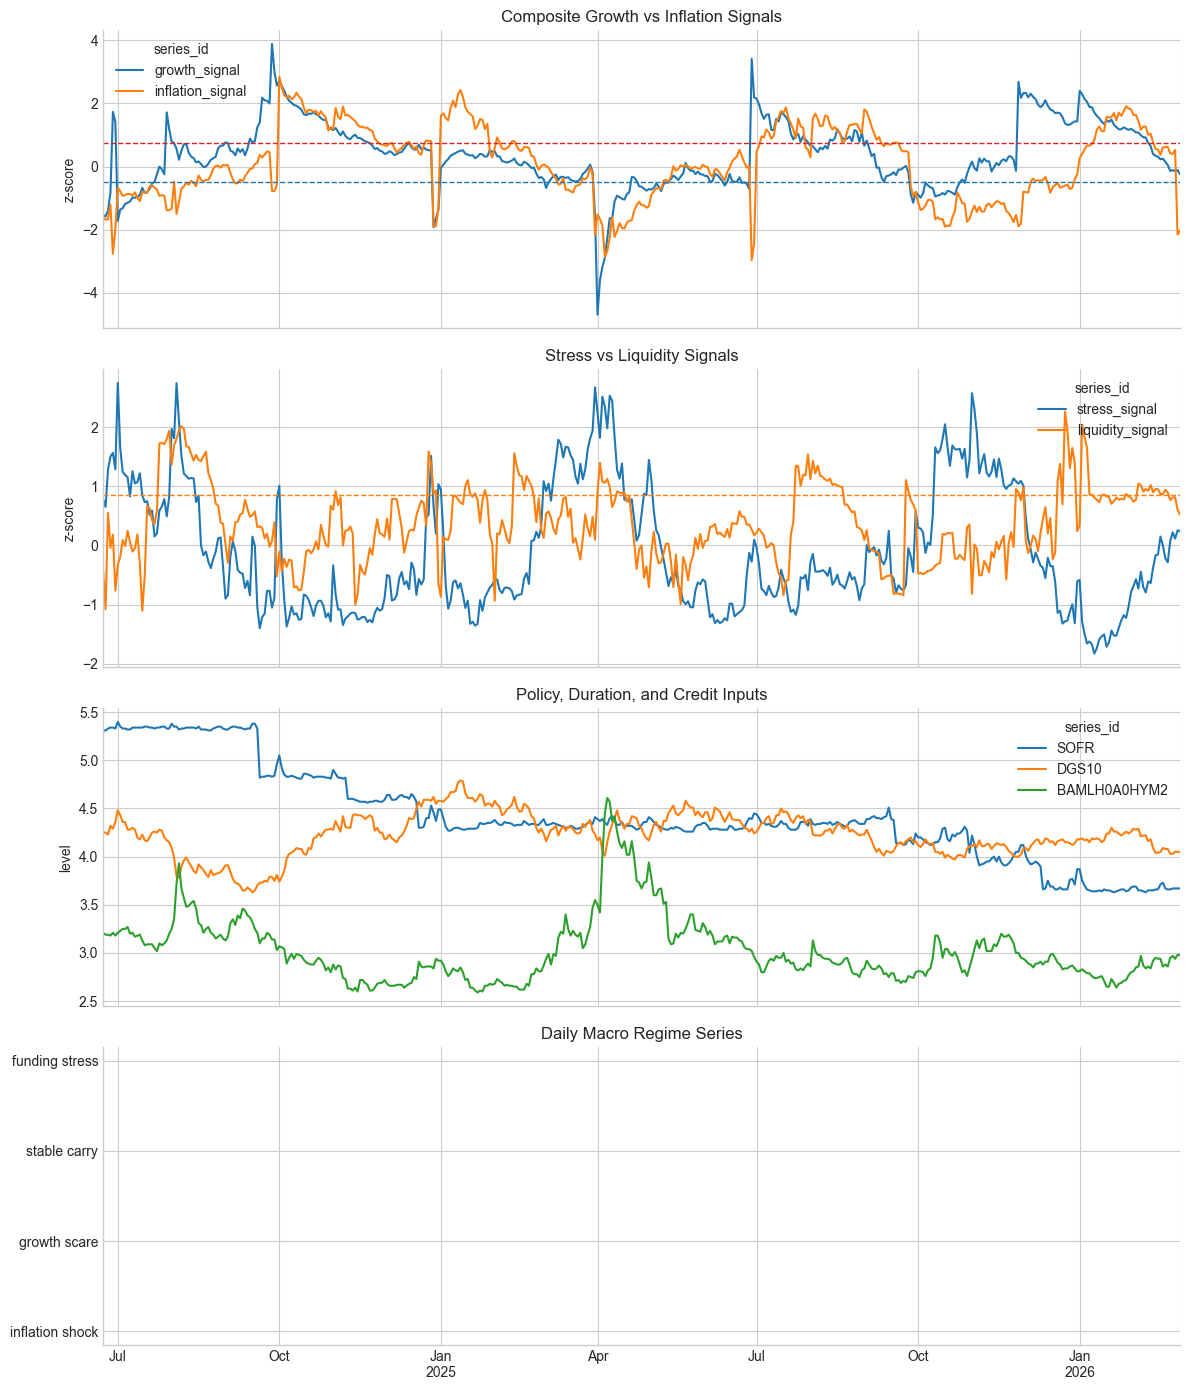

In [7]:
color_map = {
    "inflation shock": "tab:red",
    "growth scare": "tab:blue",
    "stable carry": "tab:green",
    "funding stress": "tab:orange",
}

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

regime_panel[["growth_signal", "inflation_signal"]].plot(ax=axes[0], title="Composite Growth vs Inflation Signals")
axes[0].axhline(0.75, color="tab:red", linestyle="--", linewidth=1)
axes[0].axhline(-0.50, color="tab:blue", linestyle="--", linewidth=1)
axes[0].set_ylabel("z-score")

regime_panel[["stress_signal", "liquidity_signal"]].plot(ax=axes[1], title="Stress vs Liquidity Signals")
axes[1].axhline(0.85, color="tab:orange", linestyle="--", linewidth=1)
axes[1].set_ylabel("z-score")

regime_panel[["SOFR", "DGS10", "BAMLH0A0HYM2"]].plot(ax=axes[2], title="Policy, Duration, and Credit Inputs")
axes[2].set_ylabel("level")

axes[3].scatter(
    regime_panel.index,
    regime_panel["regime_code"],
    c=regime_panel["regime"].map(color_map),
    s=10,
)
axes[3].set_yticks([0, 1, 2, 3])
axes[3].set_yticklabels(["inflation shock", "growth scare", "stable carry", "funding stress"])
axes[3].set_title("Daily Macro Regime Series")

plt.tight_layout()
plt.show()


In [8]:
asset_prices = load_local_price_series(["SPY", "DX-Y.NYB", "GC=F", "CL=F"]).sort_index()
asset_returns = np.log(asset_prices).diff()
asset_panel = asset_returns.join(regime_panel[["regime"]], how="inner").dropna()

asset_mean_bps = asset_panel.groupby("regime")[["SPY", "DX-Y.NYB", "GC=F", "CL=F"]].mean().mul(10000.0).round(2)
asset_vol_bps = asset_panel.groupby("regime")[["SPY", "DX-Y.NYB", "GC=F", "CL=F"]].std().mul(10000.0).round(2)

asset_mean_bps = asset_mean_bps.reindex(regime_order)
asset_vol_bps = asset_vol_bps.reindex(regime_order)
regime_asset_summary = pd.concat({"mean_bps": asset_mean_bps, "vol_bps": asset_vol_bps}, axis=1)
regime_asset_summary


                mean_bps                        vol_bps                         
                     SPY DX-Y.NYB   GC=F   CL=F     SPY DX-Y.NYB    GC=F    CL=F
regime                                                                          
inflation shock    12.45     1.58  15.16  -5.12   71.54    44.84  165.11  200.40
growth scare       13.10     0.51  16.61 -18.79  100.18    47.91  160.09  236.99
stable carry        4.50    -1.54  18.91  -0.07   76.89    39.29  115.69  195.35
funding stress     -5.16    -9.14  26.80 -11.80  173.91    47.16  140.07  206.36

In [9]:
output_cols = [
    "SOFR",
    "DFEDTARU",
    "DGS10",
    "T10Y2Y",
    "T10Y3M",
    "T5YIE",
    "T10YIE",
    "BAMLH0A0HYM2",
    "NFCI",
    "WALCL",
    "WRESBAL",
    "RRPONTSYD",
    "policy_gap",
    "curve_combo",
    "breakeven_avg",
    "cpi_3m_ann",
    "unrate_3m_change",
    "sentiment_3m_change",
    "growth_signal",
    "inflation_signal",
    "stress_signal",
    "liquidity_signal",
    "regime",
    "regime_code",
]

regime_output = regime_panel[output_cols].copy()
regime_output.index.name = "date"
regime_output.to_parquet(REGIME_PARQUET)
regime_output.to_csv(REGIME_CSV)
regime_asset_summary.to_csv(ASSET_SUMMARY_CSV)

print("saved regime parquet to", REGIME_PARQUET)
print("saved regime csv to", REGIME_CSV)
print("saved asset summary csv to", ASSET_SUMMARY_CSV)
regime_output.tail()


saved regime parquet to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-27_global_macro_trading_gliner/macro_regime_daily.parquet
saved regime csv to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-27_global_macro_trading_gliner/macro_regime_daily.csv
saved asset summary csv to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-27_global_macro_trading_gliner/macro_regime_asset_summary.csv


series_id   SOFR  DFEDTARU  DGS10  T10Y2Y  T10Y3M  T5YIE  T10YIE  BAMLH0A0HYM2     NFCI      WALCL    WRESBAL  RRPONTSYD  policy_gap  curve_combo  breakeven_avg  cpi_3m_ann  unrate_3m_change  sentiment_3m_change  growth_signal  inflation_signal  stress_signal  liquidity_signal        regime  regime_code
date                                                                                                                                                                                                                                                                                                            
2026-02-23  3.66      3.75   4.03    0.60    0.34   2.40    2.26          2.95 -0.56294  6613395.0  2949804.0      0.877       -0.09        0.470          2.330    2.921887              -0.1                  2.8      -0.140506          0.418226       0.071416          0.769770  stable carry            2
2026-02-24  3.67      3.75   4.03    0.61    0.35   2.40    2.26          2.97 -0.562

## Import Contract

Other notebooks in this study should load `macro_regime_daily.parquet` from this folder and merge on the daily index.

This panel is descriptive, rule-based, and intentionally simple. If you promote it into a strategy overlay, convert the current rolling signal construction into a stricter point-in-time production pipeline and re-test the thresholds.
